In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler


# Solo dos dimensiones

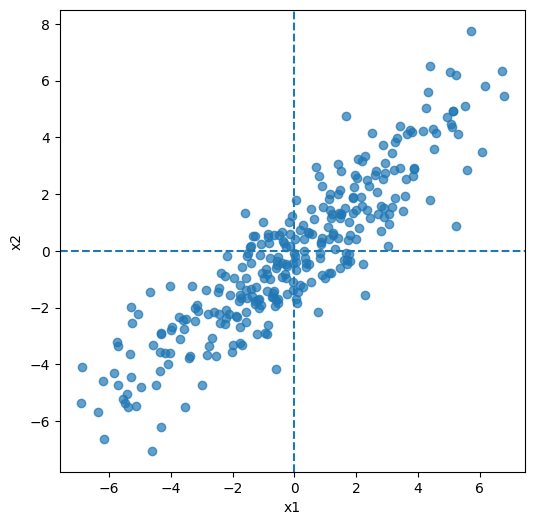

In [19]:
np.random.seed(7)

n = 300

x1 = np.random.normal(loc=0.0, scale=3.0, size=n)
x2 = 0.8 * x1 + np.random.normal(loc=0.0, scale=1.2, size=n)

X = np.column_stack([x1, x2])

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [20]:
def PCAscratch(X, n_components):
    # Media muestral
    mean = np.mean(X, axis=0)

    # Centrado
    X_centered = X - mean

    # Matriz de covarianza
    cov = np.cov(X_centered, rowvar=False)

    # Eigen-descomposición
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Ordenar de mayor a menor eigenvalor
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Seleccionar componentes principales
    components = eigenvectors[:, :n_components]

    # 7Proyección al nuevo espacio
    X_proj = X_centered @ components

    # Reconstrucción al espacio original
    X_reconstructed = X_proj @ components.T + mean

    # Varianza explicada
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

    return {
        "mean": mean,
        "X_centered": X_centered,
        "cov": cov,
        "eigenvalues": eigenvalues,
        "eigenvectors": eigenvectors,
        "components": components,
        "X_proj": X_proj,
        "X_reconstructed": X_reconstructed,
        "explained_variance_ratio": explained_variance_ratio
    }


In [21]:
result = PCAscratch(X, n_components=2)

print("Media:",result["mean"])
print("Matriz de covarianza:")
print(result["cov"])
print("Eigenvalores:",result["eigenvalues"])
print("Eigenvectores:")
print(result["eigenvectors"])
print("Varianza explicada:",result["explained_variance_ratio"])

Media: [-0.0624124 -0.1511779]
Matriz de covarianza:
[[8.29613629 6.90167175]
 [6.90167175 7.168819  ]]
Eigenvalores: [14.65712811  0.80782718]
Eigenvectores:
[[-0.73532267  0.67771718]
 [-0.67771718 -0.73532267]]
Varianza explicada: [0.94776401 0.05223599]


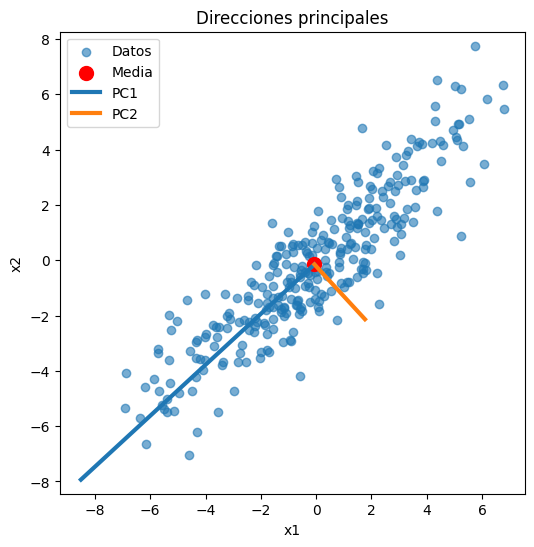

In [5]:
mean = result["mean"]
components = result["components"]
eigenvalues = result["eigenvalues"]

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, label="Datos")
plt.scatter(mean[0], mean[1], color="red", s=100, label="Media")

scale = 3.0
for i in range(2):
    direction = components[:, i]
    length = scale * np.sqrt(eigenvalues[i])
    start = mean
    end = mean + direction * length
    plt.plot(
        [start[0], end[0]],
        [start[1], end[1]],
        linewidth=3,
        label=f"PC{i+1}"
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Direcciones principales")
plt.legend()
plt.axis("equal")
plt.show()


In [6]:
result_1d = PCAscratch(X, n_components=1)

X_proj_1d = result_1d["X_proj"]
X_rec_1d  = result_1d["X_reconstructed"]

print("Primeras 10 proyecciones en 1D:")
print(X_proj_1d[:10].ravel())


Primeras 10 proyecciones en 1D:
[-6.89544323  1.77871472  1.01752788 -1.91995002  2.11662132 -0.03568566
 -0.08763834  5.44379998 -3.03216964 -1.23182361]


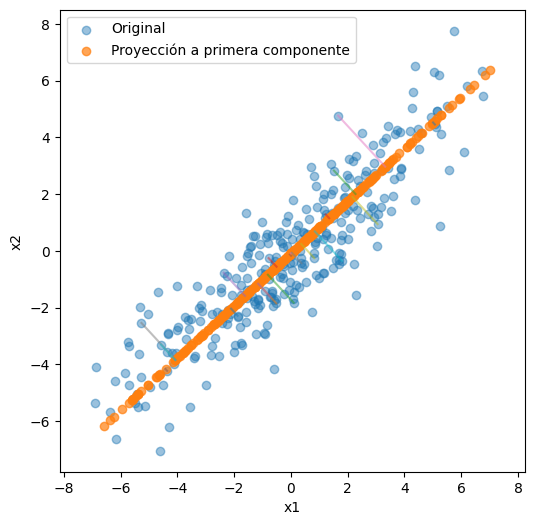

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.45, label="Original")
plt.scatter(X_rec_1d[:, 0], X_rec_1d[:, 1], alpha=0.7, label="Proyección a primera componente")

for i in range(20):
    plt.plot(
        [X[i, 0], X_rec_1d[i, 0]],
        [X[i, 1], X_rec_1d[i, 1]],
        alpha=0.5
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.axis("equal")
plt.show()


In [8]:
mse_1d = np.mean((X - X_rec_1d) ** 2)
mse_2d = np.mean((X - result["X_reconstructed"]) ** 2)

print(f"MSE con 1 componente:  {mse_1d:.6f}")
print(f"MSE con 2 componentes: {mse_2d:.6f}")

MSE con 1 componente:  0.402567
MSE con 2 componentes: 0.000000


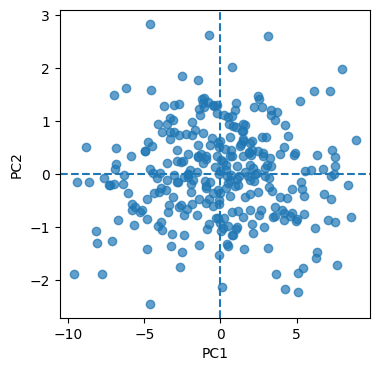

In [9]:
Z = result["X_proj"]

plt.figure(figsize=(4, 4))
plt.scatter(Z[:, 0], Z[:, 1], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [10]:
explained = result["explained_variance_ratio"]
cumulative = np.cumsum(explained)

print("Varianza explicada por componente:")
for i, v in enumerate(explained, start=1):
    print(f"PC{i}: {v:.4f}")

print("\nVarianza explicada acumulada:")
for i, v in enumerate(cumulative, start=1):
    print(f"PC1..PC{i}: {v:.4f}")


Varianza explicada por componente:
PC1: 0.9478
PC2: 0.0522

Varianza explicada acumulada:
PC1..PC1: 0.9478
PC1..PC2: 1.0000


# Efecto de la escala

In [11]:
np.random.seed(21)

n = 250
a = np.random.normal(0, 1, n)
b = 0.5 * a + np.random.normal(0, 0.3, n)
c = 100 * np.random.normal(0, 1, n)

X_scale = np.column_stack([a, b, c])

In [12]:
res_no_std = PCAscratch(X_scale, n_components=3)

print("Varianza explicada sin estandarizar:")
print(res_no_std["explained_variance_ratio"])
print()

print("Componentes sin estandarizar:")
print(res_no_std["components"])


Varianza explicada sin estandarizar:
[9.99870621e-01 1.23286042e-04 6.09271251e-06]

Componentes sin estandarizar:
[[-1.03098091e-04  8.73197977e-01 -4.87365656e-01]
 [-2.03616195e-05  4.87365657e-01  8.73197982e-01]
 [ 9.99999994e-01  9.99485994e-05 -3.24667440e-05]]


In [13]:
X_scale_std = StandardScaler().fit_transform(X_scale)
res_std = PCAscratch(X_scale_std, n_components=3)

print("Varianza explicada estandarizando:")
print(res_std["explained_variance_ratio"])
print()

print("Componentes estandarizando:")
print(res_std["components"])


Varianza explicada estandarizando:
[0.62549496 0.33330529 0.04119974]

Componentes estandarizando:
[[-0.7070842   0.00398586 -0.70711813]
 [-0.70703859  0.01203727  0.70707251]
 [ 0.01133006  0.99991961 -0.00569321]]


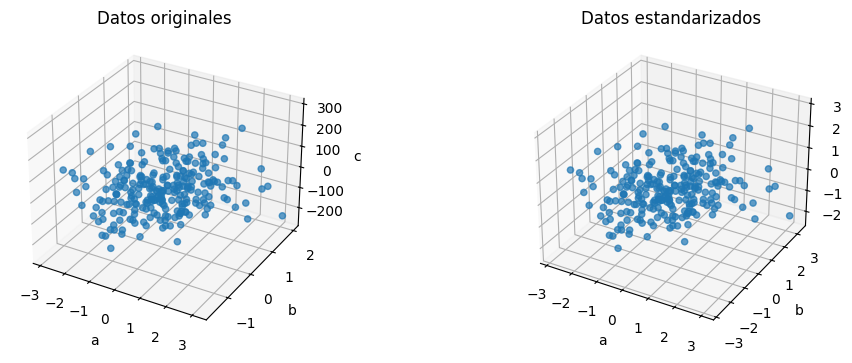

In [14]:
fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(X_scale[:, 0], X_scale[:, 1], X_scale[:, 2], alpha=0.7)
ax1.set_title("Datos originales")
ax1.set_xlabel("a")
ax1.set_ylabel("b")
ax1.set_zlabel("c")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(X_scale_std[:, 0], X_scale_std[:, 1], X_scale_std[:, 2], alpha=0.7)
ax2.set_title("Datos estandarizados")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("c")

plt.show()


# Sklearn

In [15]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X = iris.data

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

print("Shape original:", X.shape)
print("Shape reducido:", X_reduced.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Explained variance ratio acumulada:", pca.explained_variance_ratio_.cumsum())


Shape original: (150, 4)
Shape reducido: (150, 2)
Explained variance ratio: [0.72962445 0.22850762]
Explained variance ratio acumulada: [0.72962445 0.95813207]


In [16]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [17]:
# Estandarizas los datos
X_std = StandardScaler().fit_transform(X)
# 90, 95, 98, 99 varianza explicada acumulada